In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import zipfile

# NOTE: The original code used `keras` + `keras_preprocessing`, which fails in this environment.
# Use `tf_keras` which is installed and stable on Kaggle images.
import tf_keras as keras
from tf_keras.models import Sequential
from tf_keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Flatten, Dense
from tf_keras.preprocessing.image import ImageDataGenerator

# Reproducibility (score-neutral, but makes runs deterministic)
import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)



2026-01-11 00:22:11.168681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768090931.181876      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768090931.186035      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-11 00:22:11.202162: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
train_data = pd.read_csv(
    "/kaggle/input/aerial-cactus-identification/train.csv", dtype=str
)
test_data = pd.read_csv(
    "/kaggle/input/aerial-cactus-identification/sample_submission.csv", dtype=str
)

# Ensure label is string for categorical mode
train_data["has_cactus"] = train_data["has_cactus"].astype(str)

train_data.head()



,id,has_cactus
0,2de8f189f1dce439766637e75df0ee27.jpg,1
1,36704d250f236238e7f996812c48235d.jpg,1
2,eacde22fdc8c175972a5768e3daa8bc9.jpg,1
3,5d442f834da5e57d22b24802c32a8ca8.jpg,1
4,152491e0daf75c0e669400300ff7e645.jpg,1


In [3]:
train_data.describe()



,id,has_cactus
count,14175,14175
unique,14175,2
top,2de8f189f1dce439766637e75df0ee27.jpg,1
freq,1,10628


In [4]:
test_data.describe()



,id,has_cactus
count,3325,3325
unique,3325,1
top,09034a34de0e2015a8a28dfe18f423f6.jpg,0.5
freq,1,3325


In [5]:
# No need to unzip: images already exist under /kaggle/input/aerial-cactus-identification/{train,test}
train_path = "/kaggle/input/aerial-cactus-identification/train"
test_path = "/kaggle/input/aerial-cactus-identification/test"

print("Training Images:", len(os.listdir(train_path)))
print("Testing Images: ", len(os.listdir(test_path)))



Training Images: 14176
Testing Images:  3326


In [6]:
train_datagen = ImageDataGenerator(rescale=1 / 255, validation_split=0.20)
test_datagen = ImageDataGenerator(rescale=1 / 255)



In [7]:
bs = 100

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_path,
    x_col="id",
    y_col="has_cactus",
    subset="training",
    batch_size=bs,
    shuffle=True,
    class_mode="categorical",
    target_size=(32, 32),
    seed=SEED,
)

valid_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory=train_path,
    x_col="id",
    y_col="has_cactus",
    subset="validation",
    batch_size=bs,
    shuffle=True,
    class_mode="categorical",
    target_size=(32, 32),
    seed=SEED,
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory=test_path,
    x_col="id",
    y_col=None,
    batch_size=bs,
    seed=SEED,
    shuffle=False,
    class_mode=None,
    target_size=(32, 32),
)



Found 11340 validated image filenames belonging to 2 classes.
Found 2835 validated image filenames belonging to 2 classes.
Found 3325 validated image filenames.


In [8]:
# Use generator sizes directly to avoid mismatch bugs
tr_steps = math.ceil(train_generator.n / bs)
va_steps = math.ceil(valid_generator.n / bs)
te_steps = math.ceil(test_generator.n / bs)

tr_steps, va_steps, te_steps



(114, 29, 34)

In [9]:
cnn = Sequential()

cnn.add(Conv2D(28, (3, 3), activation="relu", padding="same", input_shape=(32, 32, 3)))
cnn.add(Conv2D(28, (3, 3), activation="relu", padding="same"))
cnn.add(MaxPooling2D(2, 2))
cnn.add(BatchNormalization())

cnn.add(Conv2D(56, (3, 3), activation="relu", padding="same"))
cnn.add(Conv2D(56, (3, 3), activation="relu", padding="same"))
cnn.add(MaxPooling2D(2, 2))
cnn.add(BatchNormalization())

cnn.add(Flatten())
cnn.add(Dense(128, activation="relu"))
cnn.add(BatchNormalization())

cnn.add(Dense(2, activation="softmax"))

cnn.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 28)        784       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 28)        7084      
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 28)        0         
 D)                                                              
                                                                 
 batch_normalization (Batch  (None, 16, 16, 28)        112       
 Normalization)                                                  
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 56)        14168     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 56)        2

2026-01-11 00:22:18.294427: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768090938.294879      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:c6:00.0, compute capability: 8.6


In [10]:
opt = keras.optimizers.Adam(0.001)
cnn.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])

# Keras 3/tf_keras: use fit() (fit_generator is removed)
h1 = cnn.fit(
    train_generator,
    steps_per_epoch=tr_steps,
    epochs=80,
    validation_data=valid_generator,
    validation_steps=va_steps,
    verbose=1,
)



Epoch 1/80


I0000 00:00:1768090939.504598      63 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768090940.099228      62 service.cc:148] XLA service 0x7f567d56de30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768090940.099256      62 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-11 00:22:20.104350: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768090940.165923      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


114/114 [==============================] - 5s 26ms/step - loss: 0.1811 - accuracy: 0.9398 - val_loss: 2.6941 - val_accuracy: 0.2459
Epoch 2/80
114/114 [==============================] - 3s 23ms/step - loss: 0.0754 - accuracy: 0.9726 - val_loss: 4.3092 - val_accuracy: 0.2459
Epoch 3/80
114/114 [==============================] - 3s 24ms/step - loss: 0.0498 - accuracy: 0.9820 - val_loss: 2.4180 - val_accuracy: 0.3069
Epoch 4/80
114/114 [==============================] - 3s 24ms/step - loss: 0.0285 - accuracy: 0.9899 - val_loss: 0.1762 - val_accuracy: 0.9220
Epoch 5/80
114/114 [==============================] - 3s 24ms/step - loss: 0.0339 - accuracy: 0.9875 - val_loss: 1.0502 - val_accuracy: 0.7594
Epoch 6/80
114/114 [==============================] - 3s 24ms/step - loss: 0.0162 - accuracy: 0.9940 - val_loss: 0.6065 - val_accuracy: 0.7707
Epoch 7/80
114/114 [==============================] - 3s 24ms/step - loss: 0.0116 - accuracy: 0.9959 - val_loss: 0.0399 - val_accuracy: 0.9884
Epoch 8/80

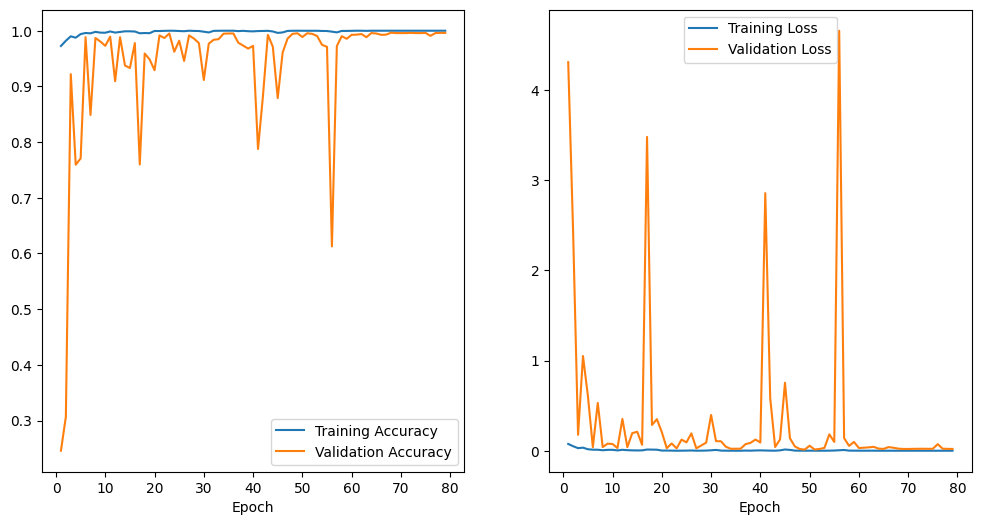

In [11]:
start = 1
ep_rng = np.arange(start, len(h1.history["accuracy"]))

plt.figure(figsize=[12, 6])
plt.subplot(1, 2, 1)
plt.plot(ep_rng, h1.history["accuracy"][start:], label="Training Accuracy")
plt.plot(ep_rng, h1.history["val_accuracy"][start:], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ep_rng, h1.history["loss"][start:], label="Training Loss")
plt.plot(ep_rng, h1.history["val_loss"][start:], label="Validation Loss")
plt.xlabel("Epoch")
plt.legend()

plt.show()



In [12]:
# Keras 3/tf_keras: use predict() (predict_generator is removed)
test_pred = cnn.predict(test_generator, steps=te_steps, verbose=1)

# Convert softmax outputs to probability of class "1"
# Flow_from_dataframe sorts class indices alphabetically: {'0':0,'1':1}
p_has_cactus = test_pred[:, 1].astype(np.float64)

# IDs must match sample submission (no directory prefix)
test_ids = test_data["id"].values

# Safety: align lengths
p_has_cactus = p_has_cactus[: len(test_ids)]

print("Pred shape:", test_pred.shape, "Output probs:", p_has_cactus.shape)
print("Prob range:", float(p_has_cactus.min()), float(p_has_cactus.max()))



34/34 [==============================] - 1s 19ms/step
Pred shape: (3325, 2) Output probs: (3325,)
Prob range: 7.195979584877462e-22 1.0


In [13]:
submission = pd.DataFrame({"id": test_ids, "has_cactus": p_has_cactus})
submission.to_csv("submission.csv", index=False)
submission.head()



,id,has_cactus
0,09034a34de0e2015a8a28dfe18f423f6.jpg,1.0
1,134f04305c795d6d202502c2ce3578f3.jpg,1.0
2,41fad8d145e6c41868ce3617e30a2545.jpg,1.0
3,35f8a11352c8d41b6231bb33d8d09f7e.jpg,1.0
4,b77dc902b035887cbbc01920ce0e3151.jpg,1.0


In [14]:
# Optional cleanup (avoid crashing if paths don't exist in /kaggle/working)
import shutil

for p in ["/kaggle/working/train", "/kaggle/working/test"]:
    if os.path.exists(p):
        shutil.rmtree(p)
print("Done. Wrote submission.csv")

Done. Wrote submission.csv
